Train size: 42000
Validation size: 6000
Test size: 12000
Epoch 1/10


/home/apd/code/CSE_Lab/CSE_4_1/myenv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


329/329 - 2s - 6ms/step - accuracy: 0.9270 - loss: 0.1900 - val_accuracy: 0.9722 - val_loss: 0.0806
Epoch 2/10
329/329 - 1s - 3ms/step - accuracy: 0.9699 - loss: 0.0869 - val_accuracy: 0.9787 - val_loss: 0.0616
Epoch 3/10
329/329 - 1s - 4ms/step - accuracy: 0.9765 - loss: 0.0680 - val_accuracy: 0.9813 - val_loss: 0.0558
Epoch 4/10
329/329 - 1s - 3ms/step - accuracy: 0.9815 - loss: 0.0549 - val_accuracy: 0.9835 - val_loss: 0.0488
Epoch 5/10
329/329 - 1s - 3ms/step - accuracy: 0.9833 - loss: 0.0493 - val_accuracy: 0.9860 - val_loss: 0.0460
Epoch 6/10
329/329 - 1s - 3ms/step - accuracy: 0.9845 - loss: 0.0439 - val_accuracy: 0.9832 - val_loss: 0.0501
Epoch 7/10
329/329 - 1s - 3ms/step - accuracy: 0.9875 - loss: 0.0379 - val_accuracy: 0.9855 - val_loss: 0.0483
Epoch 8/10
329/329 - 1s - 3ms/step - accuracy: 0.9876 - loss: 0.0358 - val_accuracy: 0.9850 - val_loss: 0.0481
Epoch 9/10
329/329 - 1s - 3ms/step - accuracy: 0.9896 - loss: 0.0307 - val_accuracy: 0.9855 - val_loss: 0.0490
Epoch 10/10


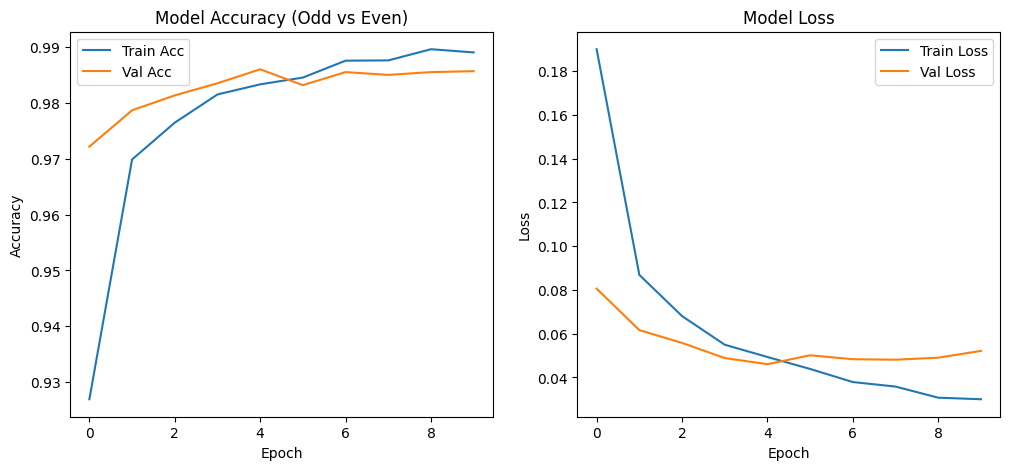

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 575us/step


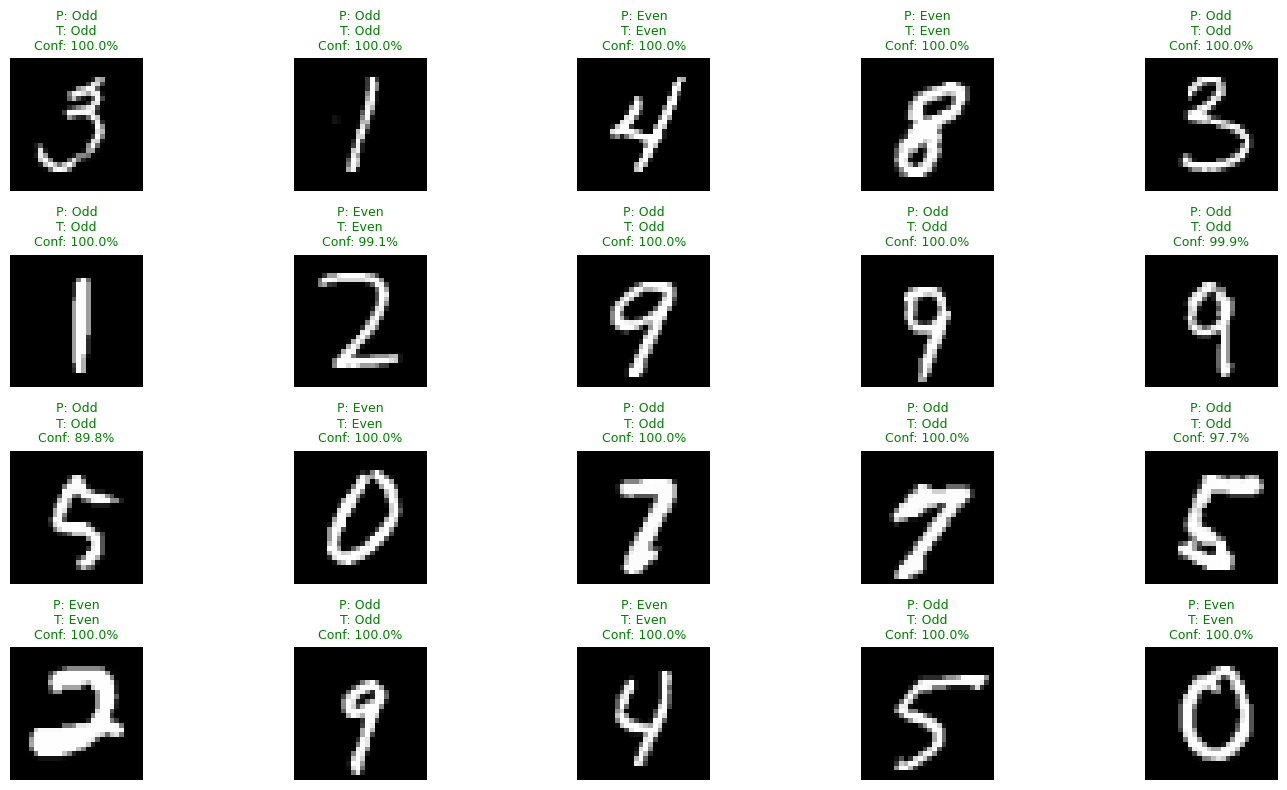

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split


# 1. Load and Preprocess Data

(x_full, y_full), (_, _) = tf.keras.datasets.mnist.load_data()

# Convert digits (0–9) into odd/even labels
y_full = (y_full % 2 != 0).astype(int)

# Normalize image pixel values
x_full = x_full.astype("float32") / 255.0
x_full = x_full.reshape(-1, 28 * 28)


# 2. Split into Train, Validation, Test

# First, split 20% test
x_trainval, x_test, y_trainval, y_test = train_test_split(
    x_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

# Now, from the remaining 80%, take 10/80 = 12.5% as validation (which is 10% of total)
x_train, x_val, y_train, y_val = train_test_split(
    x_trainval, y_trainval, test_size=0.125, random_state=42, stratify=y_trainval
)

print(f"Train size: {len(x_train)}")
print(f"Validation size: {len(x_val)}")
print(f"Test size: {len(x_test)}")


# 3. Build the Model

model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])


# 4. Compile and Train

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=2
)


# 5. Evaluate

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")
print(f"✅ Test Loss: {test_loss:.4f}")


# 6. Plot Accuracy & Loss

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy (Odd vs Even)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


# 7. Show Predictions

pred_probs = model.predict(x_test)
pred_labels = (pred_probs > 0.5).astype(int).flatten()

# Randomly select 20 samples
indices = np.random.choice(len(x_test), 20, replace=False)

plt.figure(figsize=(15, 8))
for i, idx in enumerate(indices):
    plt.subplot(4, 5, i+1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    true_label = 'Odd' if y_test[idx] == 1 else 'Even'
    pred_label = 'Odd' if pred_labels[idx] == 1 else 'Even'
    confidence = pred_probs[idx][0] * 100 if pred_labels[idx] == 1 else (1 - pred_probs[idx][0]) * 100
    color = 'green' if pred_labels[idx] == y_test[idx] else 'red'
    plt.title(f"P: {pred_label}\nT: {true_label}\nConf: {confidence:.1f}%", color=color, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()
